# TD 1 : Manipulation de données et nettoyage

La plupart de données que nous traitons sont organisées en tableaux. Une manière très répandue de stocker un tableau sont les **dataframes**. Et le package standard de python pour les dataframe s'appelle **pandas**.
Dans pandas, il y a deux structures de données principales. Ce sont les classes **DataFrame** (pour les tableaux 2D) et **Series** (pour les vecteurs 1D).

## Chargement et affichage de données
Commençons par un exemple de données de patients de cancer du sein.
La commande suivante charge un fichier en format CSV dans un pandas DataFrame et l'affiche.

In [54]:
import pandas as pd

bc = pd.read_csv("breast-cancer/breast-cancer.csv")
bc
#bc.info(verbose=True)
#bc.describe()

,class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breat-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
...,...,...,...,...,...,...,...,...,...,...
281,recurrence-events,30-39,premeno,30-34,0-2,no,2,left,left_up,no
282,recurrence-events,30-39,premeno,20-24,0-2,no,3,left,left_up,yes
283,recurrence-events,60-69,ge40,20-24,0-2,no,1,right,left_up,no
284,recurrence-events,40-49,ge40,30-34,3-5,no,3,left,left_low,no


Ce tableau contient sur chaque ligne une donnée d'un patient. 
Et dans les colonnes sont stockés les différents attributs (variables/features). 
Notons que les lignes et les colonnes ont des étiquettes (labels) (marquées en gras). Les étiquettes des lignes (ici : 0..285) sont appellés **index**.

Chaque colonne contient des données du même type, mais les différents colonnes peuvent avoir des types différents.
Par exemple, *deg-malig* est une variable **numeric** et *menopause* est une variable **catégoriel** (ou *quantitative* et *qualitative*).

Ici, il s'agit d'un problème de classification, la classe à prédire étant stockée dans la première colonne (deux classes *no-recurrence-event* et *recurrence-events*).


### Question 1.1
Quel est le type de chaque colonne/attribut ?

- class : catégoriel
- age : categoriel
- menopause : categoriel
- tumor-size : categoriel
- inv-nodes : categoriel
- node-caps : booléen
- deg-malig : numeric
- breast : categoriel
- breat-quad : catégoriel
- irradiat : booléen

### Question 1.2
Comment représenter les variables catégorielles en forme numérique ?

> sous forme de string

## Slicing et filtrage

Nous allons charger un autre jeu de données qui contient la fréquence de prénoms de nouveaux nés entre 1880 et 2012 aux États-Unis.

In [2]:
bn = pd.read_csv("babynames.csv")
bn

,year,sex,name,count,prop
0,1880,F,Mary,7065,0.072384
1,1880,F,Anna,2604,0.026679
2,1880,F,Emma,2003,0.020521
3,1880,F,Elizabeth,1939,0.019866
4,1880,F,Minnie,1746,0.017888
...,...,...,...,...,...
265872,2012,M,Gilbert,198,0.000099
265873,2012,M,Jaylon,198,0.000099
265874,2012,M,Kylen,198,0.000099
265875,2012,M,Augustine,197,0.000098


Un slice est un DataFrame qui contient une sélection de lignes ou colonnes du DataFrame original. On peut sélectionner par étiquette avec **loc** ou par indice avec **iloc**.
Ici les lignes ont des numéros comme étiquette mais ça pourrait aussi bien être des noms (comme pour les colonnes).

Syntaxe : 
```
dataframe.loc[row_label, column_label] ou
dataframe.loc[row_label] ou 
dataframe[row_label] ou alors
dataframe.row_label

dataframe.iloc[row, column] ou
dataframe.iloc[row]
```
### Question 2.1
Que font les commandes suivantes ?

In [3]:
bn.loc[3, "name"]

'Elizabeth'

In [4]:
bn.loc[3, ["name", "count"]]

name     Elizabeth
count         1939
Name: 3, dtype: object

In [5]:
bn.loc[0:10, "name":"prop"]

,name,count,prop
0,Mary,7065,0.072384
1,Anna,2604,0.026679
2,Emma,2003,0.020521
3,Elizabeth,1939,0.019866
4,Minnie,1746,0.017888
5,Margaret,1578,0.016167
6,Ida,1472,0.015081
7,Alice,1414,0.014487
8,Bertha,1320,0.013524
9,Sarah,1288,0.013196


In [6]:
bn.loc[0:3, ["name"]]

,name
0,Mary
1,Anna
2,Emma
3,Elizabeth


In [7]:
bn.loc[:,"name"]

0              Mary
1              Anna
2              Emma
3         Elizabeth
4            Minnie
            ...    
265872      Gilbert
265873       Jaylon
265874        Kylen
265875    Augustine
265876      Dangelo
Name: name, Length: 265877, dtype: object

In [8]:
# Alternative plus courte
bn["name"]

0              Mary
1              Anna
2              Emma
3         Elizabeth
4            Minnie
            ...    
265872      Gilbert
265873       Jaylon
265874        Kylen
265875    Augustine
265876      Dangelo
Name: name, Length: 265877, dtype: object

In [9]:
bn.loc[14375]
# ou bn.iloc[14375]

year         1887
sex             F
name       Amalia
count          20
prop     0.000129
Name: 14375, dtype: object

In [10]:
bn.iloc[2,3]

np.int64(2003)

In [11]:
bn.iloc[:, 2:4]

,name,count
0,Mary,7065
1,Anna,2604
2,Emma,2003
3,Elizabeth,1939
4,Minnie,1746
...,...,...
265872,Gilbert,198
265873,Jaylon,198
265874,Kylen,198
265875,Augustine,197


In [12]:
bn.iloc[-5:]

,year,sex,name,count,prop
265872,2012,M,Gilbert,198,0.000099
265873,2012,M,Jaylon,198,0.000099
265874,2012,M,Kylen,198,0.000099
265875,2012,M,Augustine,197,0.000098
265876,2012,M,Dangelo,197,0.000098


Très souvent, nous voulons filtrer un sous-ensemble de données (lignes) selon un certain critère.
Par exemple, les prénoms les plus populaires en 2012.

In [13]:
bn["year"]

0         1880
1         1880
2         1880
3         1880
4         1880
          ... 
265872    2012
265873    2012
265874    2012
265875    2012
265876    2012
Name: year, Length: 265877, dtype: int64

In [14]:
# Alternative
bn.year

0         1880
1         1880
2         1880
3         1880
4         1880
          ... 
265872    2012
265873    2012
265874    2012
265875    2012
265876    2012
Name: year, Length: 265877, dtype: int64

In [15]:
bn["year"]==2012

0         False
1         False
2         False
3         False
4         False
          ...  
265872     True
265873     True
265874     True
265875     True
265876     True
Name: year, Length: 265877, dtype: bool

Nous pouvons indexer un DataFrame un donnant cette *Series* de booléens comme argument de *loc*.

In [16]:
bn.loc[bn["year"]==2012, :]

,year,sex,name,count,prop
263877,2012,F,Sophia,22158,0.011531
263878,2012,F,Emma,20791,0.010820
263879,2012,F,Isabella,18931,0.009852
263880,2012,F,Olivia,17147,0.008923
263881,2012,F,Ava,15418,0.008024
...,...,...,...,...,...
265872,2012,M,Gilbert,198,0.000099
265873,2012,M,Jaylon,198,0.000099
265874,2012,M,Kylen,198,0.000099
265875,2012,M,Augustine,197,0.000098


In [17]:
# Raccourci
bn[bn["year"]==2012]

,year,sex,name,count,prop
263877,2012,F,Sophia,22158,0.011531
263878,2012,F,Emma,20791,0.010820
263879,2012,F,Isabella,18931,0.009852
263880,2012,F,Olivia,17147,0.008923
263881,2012,F,Ava,15418,0.008024
...,...,...,...,...,...
265872,2012,M,Gilbert,198,0.000099
265873,2012,M,Jaylon,198,0.000099
265874,2012,M,Kylen,198,0.000099
265875,2012,M,Augustine,197,0.000098


In [18]:
bn[bn["year"]==2012].sort_values('count', ascending=False)

,year,sex,name,count,prop
263877,2012,F,Sophia,22158,0.011531
263878,2012,F,Emma,20791,0.010820
263879,2012,F,Isabella,18931,0.009852
264877,2012,M,Jacob,18899,0.009404
264878,2012,M,Mason,18856,0.009383
...,...,...,...,...,...
265872,2012,M,Gilbert,198,0.000099
265869,2012,M,Apollo,198,0.000099
265870,2012,M,Denzel,198,0.000099
265876,2012,M,Dangelo,197,0.000098


On ajoute comme critère qu'on voudrait seulement les filles.

In [19]:
(bn["year"]==2012) & (bn["sex"]=="F")

0         False
1         False
2         False
3         False
4         False
          ...  
265872    False
265873    False
265874    False
265875    False
265876    False
Length: 265877, dtype: bool

In [20]:
bn[(bn["year"]==2012) & (bn["sex"]=="F")].sort_values('count', ascending=False)

,year,sex,name,count,prop
263877,2012,F,Sophia,22158,0.011531
263878,2012,F,Emma,20791,0.010820
263879,2012,F,Isabella,18931,0.009852
263880,2012,F,Olivia,17147,0.008923
263881,2012,F,Ava,15418,0.008024
...,...,...,...,...,...
264872,2012,F,Sofie,252,0.000131
264873,2012,F,Tess,252,0.000131
264874,2012,F,Ashtyn,251,0.000131
264875,2012,F,Jessa,251,0.000131


In [21]:
# Les top 10
bn[(bn["year"]==2012) & (bn["sex"]=="F")].sort_values('count', ascending=False).head(10)

,year,sex,name,count,prop
263877,2012,F,Sophia,22158,0.011531
263878,2012,F,Emma,20791,0.010820
263879,2012,F,Isabella,18931,0.009852
263880,2012,F,Olivia,17147,0.008923
263881,2012,F,Ava,15418,0.008024
263882,2012,F,Emily,13550,0.007052
263883,2012,F,Abigail,12583,0.006548
263884,2012,F,Mia,11940,0.006214
263885,2012,F,Madison,11319,0.005891
263886,2012,F,Elizabeth,9596,0.004994


### Question 2.2
Afficher les fréquences du prénom Sophia au fil des années.


In [33]:
bn.loc[bn["name"]=="Sophia", ["year", "prop"]]

,year,prop
117,1880,0.001414
2072,1881,0.001234
3992,1882,0.001547
6005,1883,0.001324
8011,1884,0.001236
...,...,...
255883,2008,0.007729
257880,2009,0.008373
259878,2010,0.010538
261877,2011,0.011293


### Question 2.3
Afficher tous les prénoms qui étaient données plus de 80000 fois dans une année.

In [34]:
bn.loc[bn["count"]>=80000, ["year", "name"]]

,year,name
126877,1943,James
132877,1946,James
132878,1946,Robert
133877,1947,Linda
134877,1947,James
...,...,...
172877,1966,Michael
174877,1967,Michael
176877,1968,Michael
178877,1969,Michael


### Question 2.4
Même question que la précedente mais afficher uniquement les prénom sans doublons (en utilisant la méthode: "unique()").

In [44]:
pd.unique(bn.loc[bn["count"]>=80000, "name"])

array(['James', 'Robert', 'Linda', 'John', 'Michael', 'David'],
      dtype=object)

### Question 2.5
Afficher tous les prénoms de filles très rares (avec une proportion < 0.01%).

In [45]:
bn.loc[bn["prop"]<0.0001, :]

,year,sex,name,count,prop
579,1880,F,Adela,9,0.000092
580,1880,F,Althea,9,0.000092
581,1880,F,Amalia,9,0.000092
582,1880,F,Amber,9,0.000092
583,1880,F,Angelina,9,0.000092
...,...,...,...,...,...
265872,2012,M,Gilbert,198,0.000099
265873,2012,M,Jaylon,198,0.000099
265874,2012,M,Kylen,198,0.000099
265875,2012,M,Augustine,197,0.000098


### Question 2.6
Analyser l'évolution de la popularité du prénom "Luna" au fil des années.


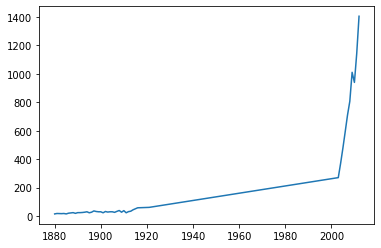

In [202]:
a = bn.loc[bn["name"]=="Luna", :].sort_values("year", ascending=True)
import matplotlib.pyplot as plt
plt.plot(a["year"], a["count"])

## Aggregation

Comme pour les bases de données et SQL, nous pouvons aggréger des lignes et appliquer des fonctions telles que min, max, count, sum...

Par exemple, pour faire la somme de toutes les naissances :

In [49]:
bn["count"].sum()

np.int64(302015867)

Groupé par année :

In [50]:
births_per_year = bn.groupby("year")["count"].sum()
births_per_year

year
1880     201194
1881     192701
1882     220902
1883     216532
1884     241959
         ...   
2008    3127240
2009    3021739
2010    2915330
2011    2882703
2012    2863986
Name: count, Length: 133, dtype: int64

Les années sont maintenant l'index du DataFrame. Si on veut réinitialiser l'index on peut le faire avec la commande suivante :

In [51]:
bpy = births_per_year.reset_index()
bpy

,year,count
0,1880,201194
1,1881,192701
2,1882,220902
3,1883,216532
4,1884,241959
...,...,...
128,2008,3127240
129,2009,3021739
130,2010,2915330
131,2011,2882703


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


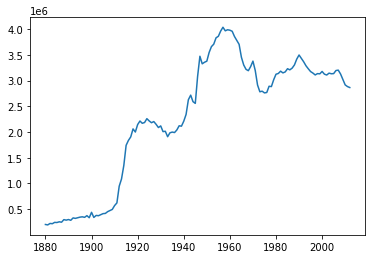

In [60]:
# Plot
import matplotlib.pyplot as plt
plt.plot(bpy["year"], bpy["count"])

On peut aussi grouper par plusieurs attributs.

In [61]:
births_per_year_and_sex = bn.groupby(["year", "sex"])["count"].sum()
births_per_year_and_sex

year  sex
1880  F        90993
      M       110201
1881  F        91955
      M       100746
1882  F       107710
              ...   
2010  M      1611151
2011  F      1290155
      M      1592548
2012  F      1283988
      M      1579998
Name: count, Length: 266, dtype: int64

In [62]:
# Converti en DataFrame
births_per_year_and_sex.to_frame()

count
year sex         
1880 F      90993
     M     110201
1881 F      91955
     M     100746
1882 F     107710
...           ...
2010 M    1611151
2011 F    1290155
     M    1592548
2012 F    1283988
     M    1579998

[266 rows x 1 columns]

In [63]:
# Avec l'index réinitalisé 
bpys = births_per_year_and_sex.reset_index()
bpys

,year,sex,count
0,1880,F,90993
1,1880,M,110201
2,1881,F,91955
3,1881,M,100746
4,1882,F,107710
...,...,...,...
261,2010,M,1611151
262,2011,F,1290155
263,2011,M,1592548
264,2012,F,1283988


Il peut être pratique de "pivoter" la table, et mettre chaque genre dans une colonne séparée.

In [64]:
pivot = pd.pivot_table(bpys, columns="sex", values="count", index="year")
pivot

sex,F,M
year,,
1880,90993.0,110201.0
1881,91955.0,100746.0
1882,107710.0,113192.0
1883,112052.0,104480.0
1884,128139.0,113820.0
...,...,...
2008,1397422.0,1729818.0
2009,1350195.0,1671544.0
2010,1304179.0,1611151.0


### Question 2.7
Étudier (visuellement) pendant quelle période et pour quel genre il y avait plus de naissances.

/tmp/ipykernel_14763/1254263285.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


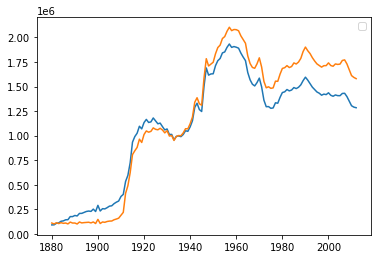

In [95]:
piv = pivot.reset_index()
piv
plt.plot(piv["year"], piv["F"], piv["year"], piv["M"])
plt.legend()

### Question 2.8
Analyser pour chaque prénom les statistiques (min, max, moyenne etc.) du nombre de naissances sur toutes les années.
(Vous pouvez utiliser la fonction *describe*.)

In [123]:
bn.groupby(["name"]).describe()

year                                                            \
         count         mean        std     min      25%     50%      75%   
name                                                                       
Aaden      5.0  2010.000000   1.581139  2008.0  2009.00  2010.0  2011.00   
Aaliyah   19.0  2003.000000   5.627314  1994.0  1998.50  2003.0  2007.50   
Aarav      5.0  2010.000000   1.581139  2008.0  2009.00  2010.0  2011.00   
Aaron    142.0  1948.091549  38.156249  1880.0  1915.25  1950.5  1980.00   
Aarush     1.0  2010.000000        NaN  2010.0  2010.00  2010.0  2010.00   
...        ...          ...        ...     ...      ...     ...      ...   
Zollie     8.0  1892.500000   7.837638  1884.0  1887.25  1890.5  1896.25   
Zona      62.0  1910.500000  18.041619  1880.0  1895.25  1910.5  1925.75   
Zora      59.0  1909.033898  17.233654  1880.0  1894.50  1909.0  1923.50   
Zula      53.0  1906.132075  15.668486  1880.0  1893.00  1906.0  1919.00   
Zuri       3.0  2011.000000   1.000000  2010.0  2010.50  2011.0  2011.50   

                 count               ...                     prop            \
            max  count         mean  ...      75%      max  count      mean   
name                                 ...                                      
Aaden    2012.0    5.0   633.400000  ...   956.00   1266.0    5.0  0.000301   
Aaliyah  2012.0   19.0  3120.631579  ...  4198.50   5471.0   19.0  0.001567   
Aarav    2012.0    5.0   359.400000  ...   436.00    438.0    5.0  0.000175   
Aaron    2012.0  142.0  3804.239437  ...  8205.50  15315.0  142.0  0.002169   
Aarush   2010.0    1.0   227.000000  ...   227.00    227.0    1.0  0.000111   
...         ...    ...          ...  ...      ...      ...    ...       ...   
Zollie   1907.0    8.0     7.875000  ...     9.50     11.0    8.0  0.000060   
Zona     1941.0   62.0    52.387097  ...    77.75    107.0   62.0  0.000094   
Zora     1939.0   59.0    77.627119  ...    93.00    169.0   59.0  0.000181   
Zula     1935.0   53.0    67.981132  ...    83.00    127.0   53.0  0.000175   
Zuri     2012.0    3.0   334.000000  ...   371.50    432.0    3.0  0.000173   

                                                                     
              std       min       25%       50%       75%       max  
name                                                                 
Aaden    0.000211  0.000110  0.000136  0.000219  0.000439  0.000598  
Aaliyah  0.000766  0.000434  0.000747  0.001728  0.002051  0.002847  
Aarav    0.000056  0.000101  0.000128  0.000214  0.000216  0.000216  
Aaron    0.002496  0.000078  0.000481  0.000713  0.003885  0.007888  
Aarush        NaN  0.000111  0.000111  0.000111  0.000111  0.000111  
...           ...       ...       ...       ...       ...       ...  
Zollie   0.000012  0.000049  0.000053  0.000055  0.000061  0.000087  
Zona     0.000032  0.000046  0.000070  0.000086  0.000115  0.000180  
Zora     0.000096  0.000049  0.000096  0.000169  0.000275  0.000422  
Zula     0.000087  0.000047  0.000095  0.000196  0.000242  0.000322  
Zuri     0.000047  0.000133  0.000147  0.000161  0.000193  0.000225  

[6949 rows x 24 columns]

## Autres opérations

Convertir des données numérique en un **numpy ndarray**.

In [124]:
bn.prop.to_numpy()

array([7.23835869e-02, 2.66789611e-02, 2.05214897e-02, ...,
       9.85252561e-05, 9.80276538e-05, 9.80276538e-05])

Ajouter une nouvelle colonne (avec la longueur de chaque prénom).

In [125]:
bn = bn.assign(nb_letters = bn["name"].str.len())
bn

,year,sex,name,count,prop,nb_letters
0,1880,F,Mary,7065,0.072384,4
1,1880,F,Anna,2604,0.026679,4
2,1880,F,Emma,2003,0.020521,4
3,1880,F,Elizabeth,1939,0.019866,9
4,1880,F,Minnie,1746,0.017888,6
...,...,...,...,...,...,...
265872,2012,M,Gilbert,198,0.000099,7
265873,2012,M,Jaylon,198,0.000099,6
265874,2012,M,Kylen,198,0.000099,5
265875,2012,M,Augustine,197,0.000098,9


Transformer un attribut de catégoriel en numérique (factorize).

In [126]:
bn.sex.factorize()


(array([0, 0, 0, ..., 1, 1, 1]), Index(['F', 'M'], dtype='object'))

In [127]:
bn.sex.factorize()[0]

array([0, 0, 0, ..., 1, 1, 1])

In [128]:
bn.sex = bn.sex.factorize()[0]
bn

,year,sex,name,count,prop,nb_letters
0,1880,0,Mary,7065,0.072384,4
1,1880,0,Anna,2604,0.026679,4
2,1880,0,Emma,2003,0.020521,4
3,1880,0,Elizabeth,1939,0.019866,9
4,1880,0,Minnie,1746,0.017888,6
...,...,...,...,...,...,...
265872,2012,1,Gilbert,198,0.000099,7
265873,2012,1,Jaylon,198,0.000099,6
265874,2012,1,Kylen,198,0.000099,5
265875,2012,1,Augustine,197,0.000098,9


Supprimer une colonne.

In [129]:
bn = bn.drop("nb_letters", axis=1)
bn

,year,sex,name,count,prop
0,1880,0,Mary,7065,0.072384
1,1880,0,Anna,2604,0.026679
2,1880,0,Emma,2003,0.020521
3,1880,0,Elizabeth,1939,0.019866
4,1880,0,Minnie,1746,0.017888
...,...,...,...,...,...
265872,2012,1,Gilbert,198,0.000099
265873,2012,1,Jaylon,198,0.000099
265874,2012,1,Kylen,198,0.000099
265875,2012,1,Augustine,197,0.000098


Nous pouvons appliquer une fonction à chaque élément d'une colonne avec **apply()**.

Exemple : longueur des prénoms

In [130]:
bn["name"].apply(len)

0         4
1         4
2         4
3         9
4         6
         ..
265872    7
265873    6
265874    5
265875    9
265876    7
Name: name, Length: 265877, dtype: int64

Autre exemple : extraire la première lettre de chaque prénom

In [131]:
def first_letter(string):
    return string[0]

bn["name"].apply(first_letter)

0         M
1         A
2         E
3         E
4         M
         ..
265872    G
265873    J
265874    K
265875    A
265876    D
Name: name, Length: 265877, dtype: object

### Question 2.9
Ajouter le résultat de cette operation comme une nouvelle colonne dans notre DataFrame, et analyser l'évolution de la fréquence des prénoms qui commence avec la lettre "L".


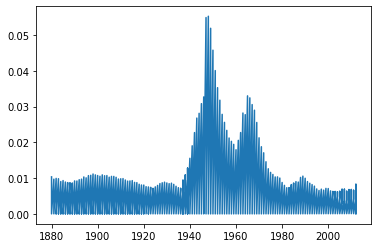

In [144]:
bn = bn.assign(first_letter = bn["name"].apply(first_letter))
fl = bn.loc[bn["first_letter"] == "L",["year","prop"]]
plt.plot(fl["year"], fl["prop"])

## Manipulation et nettoyage de données de mesures de $CO_2$

En réalité, vous aurez rarement des données si "propres" et dans le format qui convient directement pour les analyser avec python et pandas ou numpy.

Nous allons travailler sur un jeu de données avec des mesures de concentrations de $CO_2$ dans l'air. 
Elles proviennent de l'observatoire "Mauna Loa" (Hawai) de la "National Oceanic and Atmospheric Administration" (NOAA).

### Question 3.1
Ouvrez le fichier "co2_mm_mlo2.txt" avec un éditeur de texte. Et charger ce fichier (ou le fichier modifié) dans un pandas DataFrame.

In [155]:
co = pd.read_csv("co2_mm_mlo2.csv", sep="\s+")
co

,year,month,time,monthly_avg,monthly_avg_ds,nb_days,std_days,uncertainty
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
777,2023,8,2023.6250,419.68,421.57,21,0.45,0.19
778,2023,9,2023.7083,418.51,421.96,18,0.30,0.14
779,2023,10,2023.7917,418.82,422.11,27,0.47,0.17
780,2023,11,2023.8750,420.46,422.43,21,0.91,0.38


### Question 3.2
Afficher l'évolution de la moyenne mensuelle des mesures $CO_2$ au cours du temps. Qu'est que vous remarquez ? 

In [158]:
co[["year","month","monthly_avg"]]

,year,month,monthly_avg
0,1958,3,315.70
1,1958,4,317.45
2,1958,5,317.51
3,1958,6,317.24
4,1958,7,315.86
...,...,...,...
777,2023,8,419.68
778,2023,9,418.51
779,2023,10,418.82
780,2023,11,420.46


### Question 3.3
Vérifier qu'il y a bien toutes les données(12 par an) et qu'elles sont cohérentes.


In [163]:
co.groupby("year").count()["month"]

year
1958    10
1959    12
1960    10
1961    11
1962    10
        ..
2019    12
2020    12
2021    12
2022    12
2023    12
Name: month, Length: 66, dtype: int64

---
S'il y a des données manquantes, elles peuvent avoir un impact important et négatif sur notre analyse. Elle peuvent fausser nos résultats et, au pire des cas, changer nos conclusions et nos décisions. 
Donc, c'est important de les traiter correctement.

Une fois qu'on a identifié les valeurs manquantes ou erronées, il y a plusieurs manières de procéder :
1. on enlève ces lignes du tableau 
2. on les remplace par des "NaN" (Not a Number, "pandas.NA") ou une valeur "neutre" qui n'impacte pas trop l'analyse ("0" ou une moyenne ou on répète la valeur d'avant/d'aprés)
3. on fait une interpolation à partir des données "voisines" (par exemple, avant et après). 

![](addressing_missing_values.png)

Ces méthodes sont censées diminuer l'erreur du modèle, mais, en général, chacune d'elles amènent d'autres imprécisions ou biais selon la nature des données.


### Question 3.4
À partir de notre DataFrame (mlo), créer trois copies nettoyés avec les trois méthodes décrites ci-dessus.

Note : vous pouvez créer une copie d'un DataFrame avec la méthode `copy()` (exemple : `df2 = df.copy()`). Pour interpoler, utiliser la fonction `DataFrame.interpolate()`.

[1958, 1960, 1961, 1962, 1965]

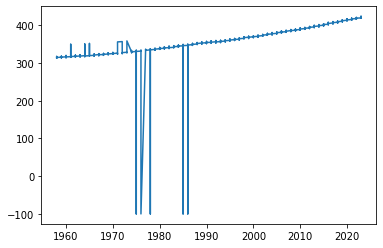

In [219]:
co3=co.copy()

# identifier les années où les mois manques
mois = co3.groupby("year").count()["month"].to_frame()
manquants = mois.loc[mois["month"] < 12, :].reset_index().year.to_list()

#tous_mois = {m for m in range(1,13)}
#for annee in manquants:
#    mois = co3.loc[co3["year"] == annee, "month"].to_list()
#    m = {mo for mo in mois}
#    mois_manquants = tous_mois-m
#    for mois_manquant in mois_manquants:
#        co3.assign(year=annee, month=mois_manquant, monthly_avg=pd.NA)
        
# enlever les annees où il n'y a pas de données
#for m in manquants:
    #co3=co3[co3["year"] != m]


plt.plot(co3["year"], co3["monthly_avg"])
manquants

Une autre manière pour les séries temporelles d'obtenir une séquence continue (c'est-à-dire sans trous) c'est d'aggréger (moyenner) les valeurs sur des périodes plus longues. Au prix d'une granularité plus grosse.
L'hypothèse c'est qu'il y a au moins une donnée par période. 

### Question 3.5
Dans l'exemple des données $CO_2$, supprimer les valeurs manquantes en aggrégeant par année. 
Note : cela enlève également les variations saissonniaires (ce qui peut être souhaitable ou non). Tracer de nouveau la courbe de la concentration $CO_2$ au fonction du temps.